<mark>Leonardo Heidi Almeida Murakami, NUSP: 11260186, Undergraduate</mark>

<mark>Use of AI-generated code is NOT RECOMMENDED </mark>: However, if you have used or relied on AI, please describe which tools and how you used them

- Simple tab complete

# MAC0460 / MAC5832 (2026) -- EP2: Logistic regression

### Objectives:

- to implement and test the logistic regression algorithm

### Submission
Submit the filled notebook, displaying the ouputs of all code cells

### Teacher's comment

I planned to update last year's EP, but unfortunately time is very short. Therefore, this notebook is practically as it was in 2025...

In the fundctions below:

- $X$ is the data matrix $N \times (d+1)$, with the transposed extended vector $\mathbf{\tilde{x}}$ in the rows

- $y$ is the target column vector $N\times 1$

- $w$ is the weight vector $(d+1)\times 1$


### For this EP we will use automatic testing

After every task, you will see a test cell to check your solution. We encourage you to experiment with these values to ensure your code is correct

In [3]:
# All imports

import numpy as np

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import pandas as pd

from sklearn.datasets import make_blobs

%matplotlib inline

# <font style="background-color:#abebc6">1. Training and prediction algorithms</font>

We will use the formulation discussed in class: we use 1 for the positive class label and 0 for the negative class label. See Section 3.3.1 of "Notas de aula".

In the next four code cells, write the code for the specified functions. These functions will be used afterwards for some training and prediction cases. Use vectorial computation with NumPy.

In [4]:
# this is the sigmoid function. Just use it
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

## <font style="background-color: #f7dc6f">1.1. Cross-entropy loss</font>

In [5]:
def cross_entropy_loss(w, X, y):
    return -(1/len(y)) * np.sum(y * np.log(sigmoid(np.dot(X, w))) + (1 - y) * np.log(1 - sigmoid(np.dot(X, w))))

In [6]:
# TEST CELL
X_test = np.array([[1., 2.], [1., 3.], [1., 4.]])
y_test = np.array([[0.], [1.], [1.]])
w_test = np.array([[0.], [1.]])
expected_cost = 0.731222
assert np.isclose(cross_entropy_loss(w_test, X_test, y_test), expected_cost, atol=1e-1), "Test for cross_entropy_loss failed"


## <font style="background-color: #f7dc6f">1.2. Gradient of the cross-entropy loss</font>

In [7]:
def cross_entropy_gradient(w, X, y):
    N = len(y)
    p = sigmoid(X @ w)
    error = p - y
    gradient = (1 / N) * X.T @ error
    return gradient

In [8]:
# TEST CELL
X_test = np.array([[5., 0.], [1., 6.], [9., 2.]])
y_test = np.array([[0.], [1.], [0.]])
w_test = np.array([[0.], [7.]])
expected_grad = np.array([[3.83333084], [0.66666611]])
assert np.allclose(cross_entropy_gradient(w_test, X_test, y_test), expected_grad, 1e-1), "Test for cross_entropy_gradient failed"


## <font style="background-color: #f7dc6f">1.3 Logistic regression training</font>

The function below receives the extended data matrix <tt> X (shape = (N, d+1))</tt> and the ouput vector <tt>y (shape = (N,1))</tt>, and should return the final weight vector <tt>w (shape = (d+1,1))</tt> and a list of size <tt>num_iterations+1</tt> with the cross-entropy loss values at the beginning and after each of the iterations, when <tt>return_history</tt> is <tt>True</tt>, or a Null list otherwise.

If <tt>w0==None</tt>, then it must be initialized  with <tt>w0 = np.random.normal(loc = 0, scale = 1, size = X.shape[1])</tt>


In [9]:
def train_logistic(X, y, learning_rate = 1e-3, w0 = None,\
                        num_iterations = 300, return_history = False):
    
    # To store the cross entropy value at each iteration
    history = []
    
    # YOUR CODE HERE
    if w0 is None:
        w0 = np.random.normal(loc = 0, scale = 1, size = X.shape[1])
    
    w = w0.reshape(-1, 1)
    for i in range(num_iterations+1):
        w = w - learning_rate * cross_entropy_gradient(w, X, y)
        if return_history:
            history.append(cross_entropy_loss(w, X, y))
    
    if return_history:
        return w, history
    else:
        return w, []


In [10]:
# TEST CELL
X_test = np.array([[1., 2.], [1., 3.], [1., 4.]])
y_test = np.array([[0.], [1.], [1.]])
w_test = np.array([[0.], [0.]])
expected_w_final = np.array([[-3.19581162], [ 1.47454342]])
learning_rate = 0.05
num_iters = 1000
expected_loss_history_length = num_iters + 1
w_final, loss_history = train_logistic(X_test, y_test, learning_rate, w_test, num_iters, return_history=True)
assert np.allclose(w_final, expected_w_final, atol=1e-1), "Test failed for train_logistic: w_final incorrect"
assert len(loss_history) == expected_loss_history_length, "Test failed for train_logistic: loss history length incorrect"

w_final, loss_history = train_logistic(X_test, y_test, learning_rate, w_test, num_iters, return_history=True)


## <font style="background-color: #f7dc6f">1.4. Logistic regression prediction</font>

The function in the next cell will be used to do the prediction. Recall that the prediction is a score in $[0,1]$, given by the sigmoid value of the linear combination.

In [11]:
def predict_logistic(X, w):
    logit = X @ w
    return sigmoid(logit)

In [12]:
# TEST CELL
X_test = np.array([[1., 2.], [1., 0.], [1., 4.]])
w_test = np.array([[0.], [1.]])
expected_predictions = np.array([[0.88079708], [0.5], [0.98201379]])
predictions = predict_logistic(X_test, w_test)
assert np.allclose(predictions, expected_predictions, atol=1e-1), "Test failed for prediction_logistic"



# <font style="background-color:#abebc6">2. Testing the training and prediction algorithms on toy datasets</font>

## 2.1. 2D data, separable case

### 2.1.1. Generate two blobs of points

---

In this code cell, change the variable `data_type` to produce different types of observations.
- "regular" corresponds to clean data with two distinct classes where a decision boundary can be drawn very easily.
- "unbalaced" is a type of dataset where one class has way more observations than the other.
- "overlapping" is a dataset where there is not a clearly distinct decision boundary to separate both classes (at least not in this dimension).

---

Play around with these dataset types and make observations.
You can also change the variable `unbalance_mod` to change the inbalance level between the classes or `overlap_std` to change how much the two classes overlap. For example, if `unbalance_mod = 10` there will be 10 times more example in class 2.

---
Note that below we keep two data matrices, X and Xtilde


In [13]:
# Create two blobs
N = 300
# change this variable to test different types of data. Possible values: "regular", "unbalanced", "overlapping".
dataset_type = "unbalanced"
# change this variable to test different magnitudes of inbalance
unbalance_mod = 5
# change this variable to test different magnitudes of overlap between classes
overlap_std = 0.5

if dataset_type == "regular":
  X, y = make_blobs(n_samples=N, centers=2, cluster_std=0.1, center_box=(-1.0, 1.0), n_features=2, random_state=2)

elif dataset_type == "unbalanced":
  X, y = make_blobs(n_samples=N, centers=2, cluster_std=0.2, center_box=(-1.0, 1.0), n_features=2, random_state=2, shuffle=False)
  len_0 = (y==0).sum()
  slice_idx = int(len_0/unbalance_mod)
  X = X[len_0-slice_idx:]
  y = y[len_0-slice_idx:]
  p = np.random.permutation(len(X))
  X = X[p]
  y = y[p]

elif dataset_type == "overlapping":
  X, y = make_blobs(n_samples=N, centers=2, cluster_std=overlap_std, center_box=(-1.0, 1.0), n_features=2, random_state=2)

else:
  raise NotImplementedError("Please choose a valid dataset_type")

# Add a bias value 1 as the first coordinate of each example
Xtilde = np.concatenate([np.ones((len(X), 1)), X], axis = 1)

y = y.reshape(len(y),1)
print("X", X.shape)
print("Xtilde", Xtilde.shape)
print("y.shape =", y.shape)


X (180, 2)
Xtilde (180, 3)
y.shape = (180, 1)


### 2.1.2. Let's plot the blobs of points

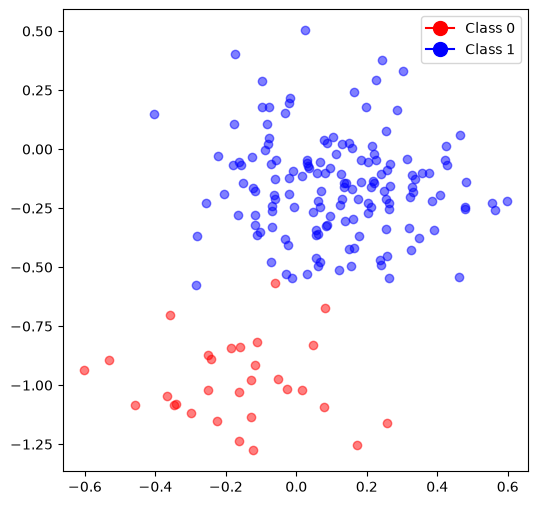

In [14]:
fig = plt.figure(figsize=(6,6))

# plot negatives in red
plt.scatter(X[y[:,0]==0,0], \
            X[y[:,0]==0,1], \
            alpha = 0.5,\
            c = 'red')

# and positives in blue
plt.scatter(x=X[y[:,0]==1,0], \
            y=X[y[:,0]==1,1], \
            alpha = 0.5, \
            c = 'blue')

P=1
N=0
legend_elements = [ Line2D([0], [0], marker='o', color='r',\
                    label='Class %d'%N, markerfacecolor='r',\
                    markersize=10),\
                    Line2D([0], [0], marker='o', color='b',\
                    label='Class %d'%P, markerfacecolor='b',\
                    markersize=10) ]

plt.legend(handles=legend_elements, loc='best')
plt.show()


### <font style="background-color: #f7dc6f">2.1.3. Let's train the logistic regressor and plot the loss curve</font>

In [15]:
def get_logistic_regression_result(Xtilde, y, learning_rate=0.5, num_iterations=1000, return_history=True):
    """
    Trains a logistic regression model using gradient descent.

    This auxiliary function wraps the call to `train_logistic()` and is 
    used to enable automatic testing of logistic regression training
    """
    np.random.seed(567) # Do not change this line!

    # ==> Replace the right hand side below with a call to the
    # train_logistic() function defined above. Use parameter return_history=True
    
    # YOUR CODE HERE
    w_logistic, loss = train_logistic(Xtilde, y, learning_rate=learning_rate, num_iterations=num_iterations, return_history=True)

    return w_logistic, loss
    
    


Final weight:
 [[5.84838854]
 [3.28437364]
 [8.2954239 ]]

Final loss:
 0.048348728181800325


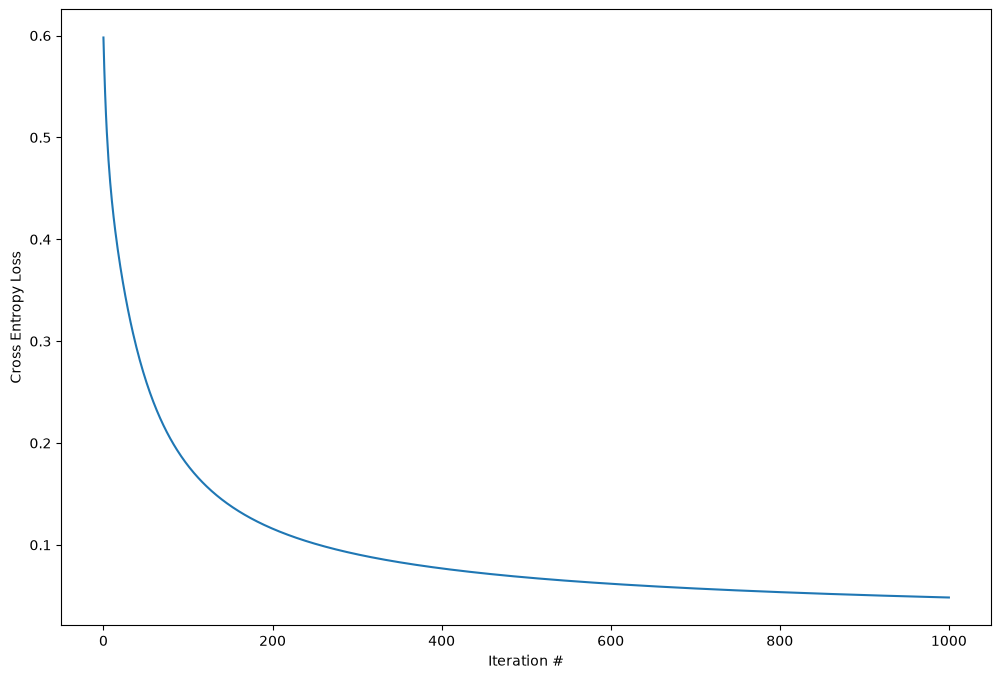

In [16]:
w_logistic, loss = get_logistic_regression_result(Xtilde, y)
print()
print("Final weight:\n", w_logistic)
print()
print("Final loss:\n", loss[-1])
    
plt.figure(figsize = (12, 8))
plt.plot(loss)
plt.xlabel('Iteration #')
plt.ylabel('Cross Entropy Loss')
plt.show()

### 2.1.4. Now, let's plot the decision boundary

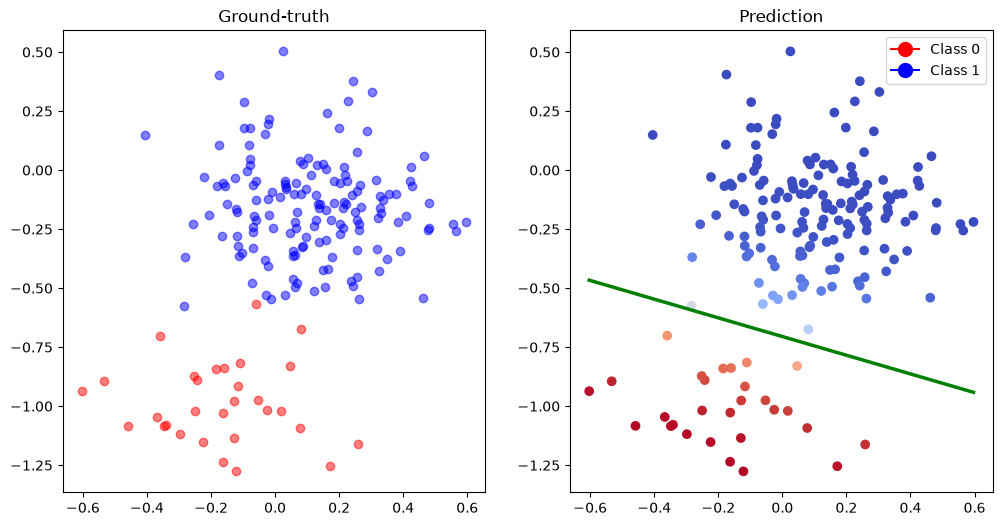

In [17]:
x1min = min(X[:,0])
x1max = max(X[:,0])
x2min = min(X[:,1])
x2max = max(X[:,1])

y_pred = predict_logistic(Xtilde, w_logistic)

fig = plt.figure(figsize=(12,6))
ax1 = fig.add_subplot(121)
ax1.set_title("Ground-truth")

# plot negatives in red
ax1.scatter(X[y[:,0]==0,0], \
            X[y[:,0]==0,1], \
            alpha = 0.5, \
            c = 'red')

# and positives in blue
ax1.scatter(x=X[y[:,0]==1,0], \
            y=X[y[:,0]==1,1], \
            alpha = 0.5, \
            c = 'blue')

ax2 = fig.add_subplot(122)

ax2.set_title("Prediction")
ax2.scatter(x = X[:,0], y = X[:,1], c = -y_pred, cmap = 'coolwarm')
ax2.legend(handles=legend_elements, loc='best')
#ax2.set_xlim([x1min-1, x1max+1])
#ax2.set_ylim([x2min-1, x2max+1])

p1 = (x1min, -(w_logistic[0] + (x1min)*w_logistic[1])/w_logistic[2])
p2 = (x1max, -(w_logistic[0] + (x1max)*w_logistic[1])/w_logistic[2])

lines = ax2.plot([p1[0], p2[0]], [p1[1], p2[1]], '-')
plt.setp(lines, color='g', linewidth=2.5)

plt.show()
        

### <font style="background-color: #f7dc6f">2.1.5.  Counting errors</font>

In [18]:
def count_errors(y, y_pred):
    """
    Function to count the numbers of missclassifications
    :param y: binary class labels
    :type y: np.ndarray of shape (N, 1)
    :param y_pred: binary class predicted labels
    :type y_pred: np.ndarray of shape (N, 1)
    """
    return np.sum(np.abs(y - y_pred) >= 0.5)

In [19]:
# TEST CELL
y_pred_test = np.array([[0.4], [0.7]])
y_test = np.array([[1.], [1.]])
expected_num_errors = 1
assert expected_num_errors == count_errors(y_test, y_pred_test), "Error for count_errors function. Wrong num of missclassfications."


In [20]:
y_pred = predict_logistic(Xtilde, w_logistic)
errors = count_errors(y, y_pred)
print("Number of misclassified examples: ", errors)

Number of misclassified examples:  2


## 2.2.  2D data, overlapping or unbalanced blobs

Feel free to experiment variations regarding total number of points, spread or number of points in each class, learning rate.

# <font style="background-color:#abebc6">3. More than 2 input variables</font>

To this end, use the dataset in <tt>dataMAC0460_5832.xlsx</tt> (same as EP1)

The goal is to predict sex, based on the remaining features. Try different combinations of the input features and see which works best. You will need to convert the categorical feature 'sex' into numerical class values 0 and 1

Create new code cells below as needed. Add comments to make them understandable.


In [33]:
# load the dataset
df=pd.read_excel('data_mac0460_5832.xlsx')

df.describe(include='all')

,Sex,Age,Height,Weight,Shoe number
count,340,340.000000,340.000000,340.000000,340.000000
unique,2,NaN,NaN,NaN,NaN
top,Male,NaN,NaN,NaN,NaN
freq,244,NaN,NaN,NaN,NaN
mean,NaN,28.250000,171.529412,71.061765,39.723529
std,NaN,12.908773,10.203057,15.599117,2.704749
min,NaN,3.000000,100.000000,15.000000,24.000000
25%,NaN,21.000000,165.000000,60.000000,38.000000
50%,NaN,23.000000,172.000000,70.000000,40.000000
75%,NaN,29.000000,179.000000,80.000000,42.000000


In [ ]:
# convert sex to binary female=1, male=0
y_real = (df['Sex'] == 'Female').astype(float).values.reshape(-1, 1)

all_features = ['Age', 'Height', 'Weight', 'Shoe number']

def normalize_features(X):
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    return (X - mean) / std

from itertools import combinations

results = []

for num_feats in range(1, len(all_features) + 1):
    for feats in combinations(all_features, num_feats):
        X_raw = df[list(feats)].values.astype(float)
        X_norm = normalize_features(X_raw)
        Xtilde_real = np.concatenate([np.ones((len(X_norm), 1)), X_norm], axis=1)
        
        np.random.seed(np.random)
        w, loss = train_logistic(Xtilde_real, y_real, learning_rate=0.5, num_iterations=2000, return_history=True)
        y_pred = predict_logistic(Xtilde_real, w)
        errors = count_errors(y_real, y_pred)
        accuracy = 1 - errors / len(y_real)
        results.append((feats, errors, accuracy, loss[-1], w, Xtilde_real, loss))

results.sort(key=lambda r: r[1])

print(f"{'Features':<35} {'Errors':>7} {'Accuracy':>10} {'Final Loss':>12}")
print("-" * 66)
for feats, errors, acc, final_loss, _, _, _ in results:
    print(f"{str(feats):<35} {errors:>7} {acc:>10.4f} {final_loss:>12.6f}")

Features                             Errors   Accuracy   Final Loss
------------------------------------------------------------------
('Age', 'Shoe number')                   29     0.9147     0.225358
('Age', 'Weight', 'Shoe number')         29     0.9147     0.224375
('Age', 'Height', 'Shoe number')         30     0.9118     0.224941
('Height', 'Weight', 'Shoe number')      30     0.9118     0.231596
('Weight', 'Shoe number')                31     0.9088     0.231599
('Age', 'Height', 'Weight', 'Shoe number')      32     0.9059     0.224222
('Shoe number',)                         33     0.9029     0.236133
('Height', 'Shoe number')                35     0.8971     0.235849
('Age', 'Height')                        43     0.8735     0.350193
('Age', 'Height', 'Weight')              45     0.8676     0.349126
('Height',)                              51     0.8500     0.364163
('Height', 'Weight')                     51     0.8500     0.364137
('Age', 'Weight')                        7

Features: ('Age', 'Shoe number')
Errors: 29/340  Accuracy: 0.9147


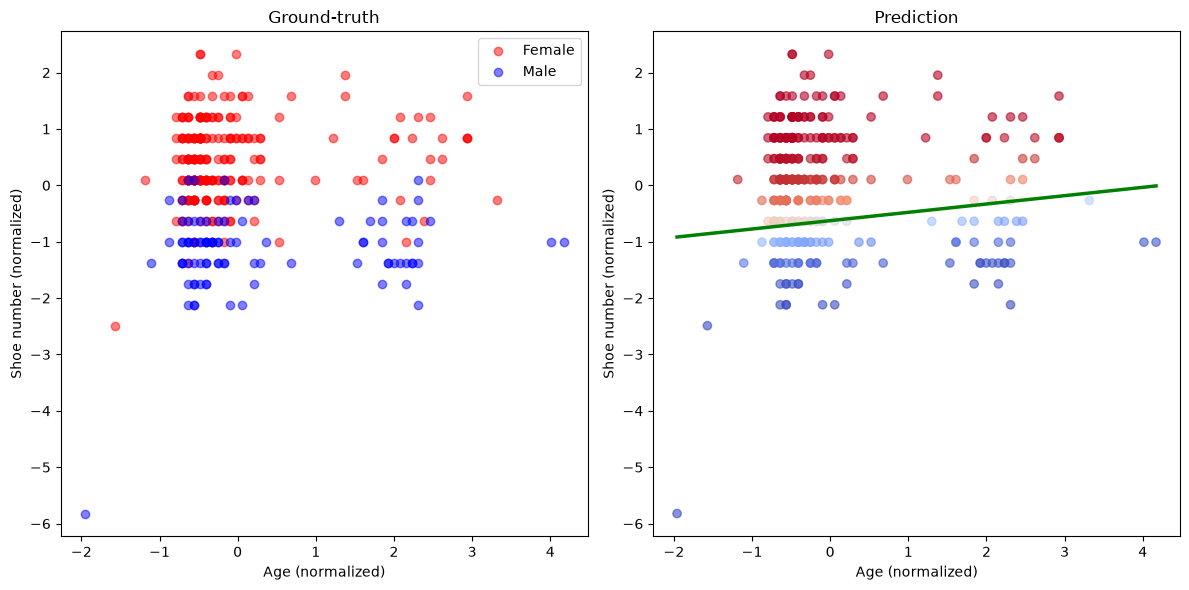

In [37]:
best_2d = None
for r in results:
    if len(r[0]) == 2:
        if best_2d is None or r[1] < best_2d[1]:
            best_2d = r

feats_2d, errors_2d, acc_2d, _, w_2d, Xtilde_2d, loss_2d = best_2d
X_2d = df[list(feats_2d)].values.astype(float)
X_2d_norm = normalize_features(X_2d)

print(f"Features: {feats_2d}")
print(f"Errors: {errors_2d}/{len(y_real)}  Accuracy: {acc_2d:.4f}")

x1min, x1max = X_2d_norm[:, 0].min(), X_2d_norm[:, 0].max()
x2min, x2max = X_2d_norm[:, 1].min(), X_2d_norm[:, 1].max()

fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(121)
ax1.set_title("Ground-truth")
ax1.scatter(X_2d_norm[y_real[:, 0] == 0, 0], X_2d_norm[y_real[:, 0] == 0, 1], alpha=0.5, c='red', label='Female')
ax1.scatter(X_2d_norm[y_real[:, 0] == 1, 0], X_2d_norm[y_real[:, 0] == 1, 1], alpha=0.5, c='blue', label='Male')
ax1.set_xlabel(feats_2d[0] + " (normalized)")
ax1.set_ylabel(feats_2d[1] + " (normalized)")
ax1.legend()

ax2 = fig.add_subplot(122)
ax2.set_title("Prediction")
y_pred_2d = predict_logistic(Xtilde_2d, w_2d)
ax2.scatter(X_2d_norm[:, 0], X_2d_norm[:, 1], c=-y_pred_2d.ravel(), cmap='coolwarm', alpha=0.6)

p1 = (x1min, -(w_2d[0] + x1min * w_2d[1]) / w_2d[2])
p2 = (x1max, -(w_2d[0] + x1max * w_2d[1]) / w_2d[2])
lines = ax2.plot([p1[0], p2[0]], [p1[1], p2[1]], '-')
plt.setp(lines, color='g', linewidth=2.5)
ax2.set_xlabel(feats_2d[0] + " (normalized)")
ax2.set_ylabel(feats_2d[1] + " (normalized)")

plt.tight_layout()
plt.show()